Deterministic matching fails due to data quality. There are typos, inconsistent formating in different dataset. For example, in one dataset, the candidate name could be the nick name while another using the full name. Besides, missing values where a field is recorded in one source but left blank in another, and measurement error such as a birthyear recorded one year off can also lead to the failure. Since deterministic matching requires every specified field to agree exactly, a single character difference is enough to cause a true match to be missed entirely.

In [5]:
###############################################################################
# Deterministic and Probabilistic Matching Tutorial + Assignment (Python)
# -----------------------------------------------------------------------------
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import recordlinkage as rl
from rapidfuzz.distance import Levenshtein
from splink import DuckDBAPI
from splink import Linker, SettingsCreator
import splink.comparison_library as cl
from datetime import date

# Generate Two Datasets

np.random.seed(123)   # Reproducibility (use the same seed each time)
n = 10000             # Target size (before drop_duplicates)


# Step 1: Create Dataset A (df_a)
first_names = ["John", "Jane", "Michael", "Emily", "David", "Sarah", "William", "Emma", "James", "Olivia"]
last_names  = ["Smith", "Johnson", "Williams", "Brown", "Jones", "Garcia", "Miller", "Davis", "Rodriguez", "Martinez"]

df_a = pd.DataFrame({
    "id": np.arange(1, n + 1),
    "firstname": np.random.choice(first_names, size=n, replace=True),
    "lastname": np.random.choice(last_names, size=n, replace=True),
    "birthyear": np.random.randint(1970, 2001, size=n),
    "zipcode": np.random.randint(10000, 20001, size=n)
})

# Mimic R's distinct(): drop duplicates across all columns
df_a = df_a.drop_duplicates().reset_index(drop=True)

# Step 2: Create Dataset B (df_b) as a copy of df_a, then add "noise"
df_b = df_a.copy()

# Decide which rows will be modified (25% probability each type of noise)
mod_firstname = np.random.rand(len(df_b)) < 0.25
mod_lastname  = np.random.rand(len(df_b)) < 0.25
mod_birthyear = np.random.rand(len(df_b)) < 0.25

# 2A: Add typos to FIRST NAMES (only for rows selected by mod_firstname)
idx_firstname = np.where(mod_firstname)[0]

for i in idx_firstname:
    firstname = df_b.loc[i, "firstname"]
    chars = list(firstname)

    num_replace = np.random.randint(1, len(chars) + 1)
    positions = np.random.choice(np.arange(len(chars)), size=num_replace, replace=False)

    for pos in positions:
        chars[pos] = np.random.choice(list("abcdefghijklmnopqrstuvwxyz"))

    df_b.loc[i, "firstname"] = "".join(chars)

# 2B: Add typos to LAST NAMES (only for rows selected by mod_lastname)
idx_lastname = np.where(mod_lastname)[0]

for i in idx_lastname:
    lastname = df_b.loc[i, "lastname"]
    chars = list(lastname)

    num_replace = np.random.randint(1, len(chars) + 1)
    positions = np.random.choice(np.arange(len(chars)), size=num_replace, replace=False)

    for pos in positions:
        chars[pos] = np.random.choice(list("abcdefghijklmnopqrstuvwxyz"))

    df_b.loc[i, "lastname"] = "".join(chars)

# 2C: Shift BIRTH YEAR slightly
idx_birthyear = np.where(mod_birthyear)[0]
birthyear_shift = np.random.choice(np.arange(-2, 3), size=len(idx_birthyear), replace=True)
df_b.loc[idx_birthyear, "birthyear"] = df_b.loc[idx_birthyear, "birthyear"].to_numpy() + birthyear_shift

# Step 3: Save datasets to CSV (so students can load them like "real" files)
df_a.to_csv("dataset_a.csv", index=False)
df_b.to_csv("dataset_b.csv", index=False)

# Part 1: Student Assignment Starts Here
# Your task is to perform both deterministic and probabilistic matching on these
# two datasets. Follow the steps below and answer the questions at the end.

# -----------------------------------------------------------------------------
# Step 1: Load the datasets
# -----------------------------------------------------------------------------
df_a = pd.read_csv("dataset_a.csv")
df_b = pd.read_csv("dataset_b.csv")

# Set id as the index (helps later when we work with record linkage pairs)
df_a = df_a.set_index("id")
df_b = df_b.set_index("id")

# -----------------------------------------------------------------------------
# Step 2: Examine the datasets
# -----------------------------------------------------------------------------
# describe() gives distributions and missingness
# head() shows the first few rows

print(df_a.describe(include="all"))
print(df_a.head())

print(df_b.describe(include="all"))
print(df_b.head())

# Q4 Deterministic matching (exact matching)

det_matches = (
    df_a.reset_index()
      .merge(
          df_b.reset_index(),
          on=["firstname", "lastname", "birthyear", "zipcode"],
          how="inner",
          suffixes=(".a", ".b")
      )
)

print("Number of deterministic matches:", det_matches.shape[0])

match_ratio = det_matches.shape[0]/df_a.shape[0]
print('Match ratio:', match_ratio)


       firstname  lastname     birthyear       zipcode
count      10000     10000  10000.000000  10000.000000
unique        10        10           NaN           NaN
top         John  Williams           NaN           NaN
freq        1027      1073           NaN           NaN
mean         NaN       NaN   1984.998600  14962.482200
std          NaN       NaN      8.959868   2906.032953
min          NaN       NaN   1970.000000  10000.000000
25%          NaN       NaN   1977.000000  12435.000000
50%          NaN       NaN   1985.000000  14956.500000
75%          NaN       NaN   1993.000000  17473.750000
max          NaN       NaN   2000.000000  19998.000000
   firstname lastname  birthyear  zipcode
id                                       
1    Michael    Smith       1970    18323
2    Michael  Johnson       1989    14381
3    William    Davis       1995    13056
4       Jane    Jones       1992    10471
5      Emily    Jones       1996    19860
       firstname  lastname     birthyear      

There are altogether 4559 entities are matched in data a and data b. The match ratio is 0.45. The reason for that is we set a probabilistic typo into the two dataset, and the deterministic matching only matches where all variables are the same. Therefore, we only have part of the records meet the requirement.

You are using the default value for `max_pairs`, which may be too small and thus lead to inaccurate estimates for your model's u-parameters. Consider increasing to 1e8 or 1e9, which will result in more accurate estimates, but with a longer run time.
----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - firstname (no m values are trained).
    - lastname (no m values are trained).
    - birthyear (no m values are trained).
    - zipcode (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
l."firstname" = r."firstname"

Parameter estimates will be made for the following comparison(s):
    - lastname
    - birthyear
    - zipcode

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - firstname

Iteration 1: Largest change in param

   unique_id_l  unique_id_r  match_probability
0            0        10000           0.810840
1            1        10001           0.996263
2            2        10002           0.996263
3            3        10312           0.012250
4            4        10787           0.000199


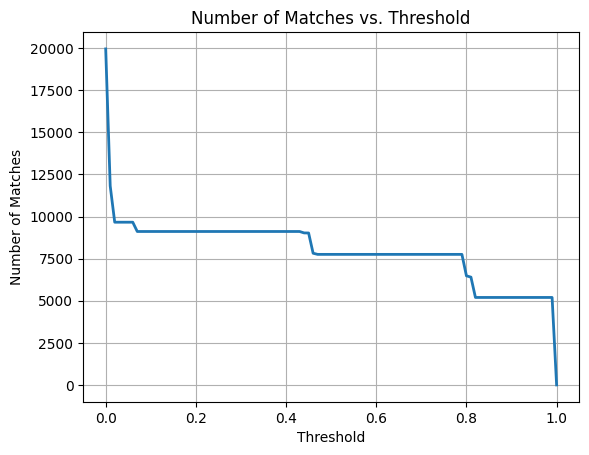

In [31]:

# Probabilistic matching using recordlinkage

# recordlinkage workflow:
#   1) Create candidate pairs (indexing / blocking)
#   2) Compare fields to create similarity features
#   3) Fit an unsupervised probabilistic model (ECMClassifier)
#   4) Get match probabilities ("posterior") for candidate pairs

# Q5 fast link
import splink
from splink import DuckDBAPI, Linker, SettingsCreator, block_on
import splink.comparison_library as cl
import warnings
warnings.filterwarnings("ignore")
db_api = DuckDBAPI()

# settings
df_a["unique_id"] = range(len(df_a))
df_b["unique_id"] = range(len(df_a), len(df_a) + len(df_b))

settings = SettingsCreator(
    unique_id_column_name="unique_id",
    link_type="link_only",  # df_a vs df_b
    blocking_rules_to_generate_predictions=[
        block_on("zipcode"),# use splink to block on zipcode to reduce pairs
    ],
    comparisons=[
        cl.JaroWinklerAtThresholds("firstname", [0.85]),   # Jaro-Winkler
        cl.JaroWinklerAtThresholds("lastname",  [0.85]),
        cl.ExactMatch("birthyear"), # exact
        cl.ExactMatch("zipcode"), # exact
    ],
)

# create linker
linker = Linker([df_a, df_b], settings, db_api=db_api)

#  ECM
# estimate u
linker.training.estimate_u_using_random_sampling(max_pairs=1e6)

# estimate m
linker.training.estimate_parameters_using_expectation_maximisation(block_on("firstname"))
linker.training.estimate_parameters_using_expectation_maximisation(block_on("lastname"))

# make prediction
predictions = linker.inference.predict(threshold_match_probability=0.0)
df_pred = predictions.as_pandas_dataframe()

print(df_pred[["unique_id_l", "unique_id_r", "match_probability"]].head())

# 5.b increase grid threshold by 0.01
thresholds = np.arange(0, 1.01, 0.01)
n_matches = []

for t in thresholds:
    n = (df_pred["match_probability"] >= t).sum()
    n_matches.append(n)

# plot
plt.plot(thresholds, n_matches, linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("Number of Matches")
plt.title("Number of Matches vs. Threshold")
plt.grid(True)
plt.show()


  threshold_bin  mean_first  mean_last  mean_birth      n
0       0.0-0.1    4.572087   5.534545    9.435661  10841
1       0.1-0.2         NaN        NaN         NaN      0
2       0.2-0.3         NaN        NaN         NaN      0
3       0.3-0.4         NaN        NaN         NaN      0
4       0.4-0.5    0.056659   0.086093    1.857984   1359
5       0.5-0.6         NaN        NaN         NaN      0
6       0.6-0.7         NaN        NaN         NaN      0
7       0.7-0.8    0.245683   4.069859    0.000000   1274
8       0.8-0.9    3.370717   0.262461    0.000000   1284
9       0.9-1.0    0.067385   0.073931    0.000000   5194


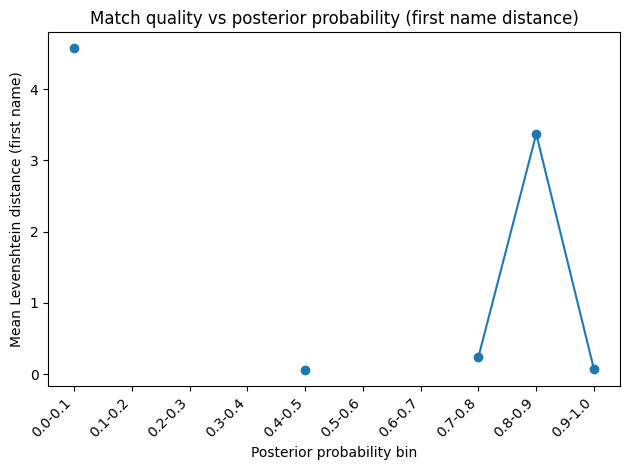

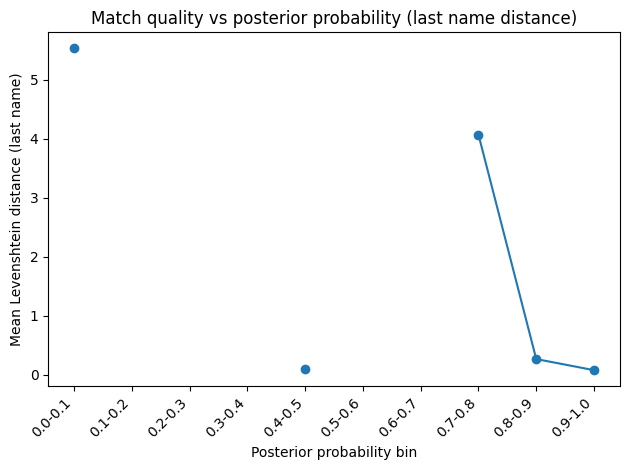

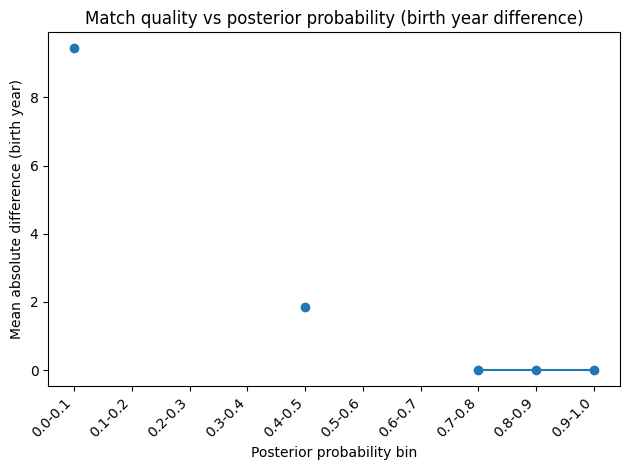

df_a unique_id range: 0 to 9999
df_b unique_id range: 10000 to 19999


In [32]:
# Q6  Analyze how the match threshold affects the number of matches

# Match quality vs posterior probability (string distance diagnostics)
# Idea:
# - Keep a very low threshold so we get "almost everything"
# - Bin matches into posterior-probability bins:
#     (0.0, 0.1], (0.1, 0.2], ..., (0.9, 1.0]
# - For each bin, compute:
#     * Levenshtein distance for first names
#     * Levenshtein distance for last names
#     * absolute difference in birth year
#
# Interpretation:
# - If posterior is doing what we want, then higher posterior bins should have:
#     * smaller string distances
#     * smaller birth-year differences
posterior_df = df_pred[["unique_id_l", "unique_id_r", "match_probability"]].copy()
posterior_df = posterior_df.rename(columns={"match_probability": "posterior"})
matches_low = posterior_df[posterior_df["posterior"] > 0.000001].copy()

bin_edges = np.arange(0.0, 1.0000001, 0.1)
bin_labels = [
    "0.0-0.1", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5",
    "0.5-0.6", "0.6-0.7", "0.7-0.8", "0.8-0.9", "0.9-1.0"
]

matches_low["threshold_bin"] = pd.cut(
    matches_low["posterior"],
    bins=bin_edges,
    labels=bin_labels,
    right=True
)

# Join pair rows back to df_a and df_b so we can compare fields
# df_a
pairs_plus_a = matches_low.merge(
    df_a.reset_index(),
    left_on="unique_id_l",
    right_on="unique_id",
    how="left"
)
pairs_plus_a = pairs_plus_a.rename(columns={
    "firstname": "firstname_a",
    "lastname":  "lastname_a",
    "birthyear": "birthyear_a",
    "zipcode":   "zipcode_a"
})

# merge df_b
pairs_plus_ab = pairs_plus_a.merge(
    df_b.reset_index(),
    left_on="unique_id_r",
    right_on="unique_id",
    how="left"
)
pairs_plus_ab = pairs_plus_ab.rename(columns={
    "firstname": "firstname_b",
    "lastname":  "lastname_b",
    "birthyear": "birthyear_b",
    "zipcode":   "zipcode_b"
})

# (a) Levenshtein distance for first names
pairs_plus_ab["first_name_distance"] = [
    Levenshtein.distance(a, b) for a, b in zip(pairs_plus_ab["firstname_a"], pairs_plus_ab["firstname_b"])
]
# (b) Levenshtein distance for last names
pairs_plus_ab["last_name_distance"] = [
    Levenshtein.distance(a, b) for a, b in zip(pairs_plus_ab["lastname_a"], pairs_plus_ab["lastname_b"])
]

# (c) Compute birthyear distance: absolute difference
pairs_plus_ab["birth_year_distance"] = (pairs_plus_ab["birthyear_a"] - pairs_plus_ab["birthyear_b"]).abs()

# Average distance by posterior bin (mean distances + counts)
avg_dist_by_bin = (
    pairs_plus_ab
    .groupby("threshold_bin", observed=False)
    .agg(
        mean_first=("first_name_distance", "mean"),
        mean_last=("last_name_distance", "mean"),
        mean_birth=("birth_year_distance", "mean"),
        n=("posterior", "size")
    )
    .reset_index()
)

print(avg_dist_by_bin)

# Plot: mean first-name distance by posterior bin
plt.figure()
plt.plot(avg_dist_by_bin["threshold_bin"].astype(str), avg_dist_by_bin["mean_first"], marker="o")
plt.xlabel("Posterior probability bin")
plt.ylabel("Mean Levenshtein distance (first name)")
plt.title("Match quality vs posterior probability (first name distance)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot: mean last-name distance by posterior bin
plt.figure()
plt.plot(avg_dist_by_bin["threshold_bin"].astype(str), avg_dist_by_bin["mean_last"], marker="o")
plt.xlabel("Posterior probability bin")
plt.ylabel("Mean Levenshtein distance (last name)")
plt.title("Match quality vs posterior probability (last name distance)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot: mean birthyear distance by posterior bin
plt.figure()
plt.plot(avg_dist_by_bin["threshold_bin"].astype(str), avg_dist_by_bin["mean_birth"], marker="o")
plt.xlabel("Posterior probability bin")
plt.ylabel("Mean absolute difference (birth year)")
plt.title("Match quality vs posterior probability (birth year difference)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# campare number of matches using threshold at 0.5
n_prob = (df_pred["match_probability"] >= 0.5).sum()
print("Deterministic matches:", det_matches.shape[0])
print("Probabilistic matches (t=0.5):", n_prob)
print("Difference:", n_prob - det_matches.shape[0])

Discussion:
I compare probabilistic matching at 0.5 threshold and deterministic matching. Deterministic matching recovered 4,559 matches, while probabilistic matching at threshold 0.5 recovered 7,752. This gap is due to the noise injected into df_b: with 25% of names containing typos and 25% of birth years shifted, roughly 56% of true matches have at least one modified field.

As the threshold increases from 0 to 1, the number of matches decreases in a staircase pattern rather. At t=0, all candidate pairs sharing a zipcode are included. The first steep drop occurs around t=0.05, cutting the count to around 9,500. It eliminated pairs share only a zipcode but disagree on other fields. A final drop near t=0.80 brings the count to about 5,200, leaving only highly confident matches. Because each field contributes a log-weight to the posterior, match probabilities cluster at specific values.

Limitations and bias:
Deterministic matching has two key limitations. First, it has very low recall in the presence of noise — a single character typo causes a genuine match to be missed entirely. Second, it can cause false positives when common name and zipcode combinations collide across unrelated records.

Probabilistic matching also has important limitations. First, the EM algorithm treate each fields as independent. In reality certain firstnames and lastnames co-occur more frequently, causing the model to mis-estimate posterior probabilities for those combinations. Second, the model is constrained by the blocking rule. By blocking only on zipcode, any pair where zipcode was transcribed differently is never considered as a candidate.

Relationship between string distance and posterior probability:
The diagnostic plots confirm that posterior probability is a valid measure of match quality. In the lowest probability bin (0.0–0.1), mean Levenshtein distance for firstnames is THE largest in both first name and last name filed, reflecting pairs that share only a zipcode and agree on little else. Mean birthyear difference in this bin is about 9 years, consistent with random non-matching pairs. In the highest bin (0.9–1.0), both name distances drop to near zero and birthyear difference falls to zero, meaning the model's most confident matches have essentially identical fields across the board. This monotonic relationship between posterior probability and raw field similarity validates the EM model.

It's worth noting that the firstname distance plot shows an unexpected spike in the 0.8–0.9 bin, where mean Levenshtein distance rises to ~3.4 before dropping back to near zero in the 0.9–1.0 bin. This anomaly is might due to the ExactMatch on birthyear. Pairs where birthyear matches exactly receive a large fixed weight from the EM model, pushing their posterior into the 0.8–0.9 range even when firstname contains substantial typos. This reveals a limitation of the independence assumption, the model treats a perfect birthyear match as strong evidence regardless of how dissimilar the names are, producing a subset of high-posterior pairs that are not actually high quality across all fields.